In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, GRU, SimpleRNN, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# For Vision Transformer
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import ViTConfig, ViTModel

import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported')
print(f'TensorFlow version: {tf.__version__}')
print(f'PyTorch version: {torch.__version__}')


✅ Libraries imported
TensorFlow version: 2.19.0
PyTorch version: 2.10.0+cpu


In [4]:
df = pd.read_csv('Electric_Production.csv')
print(f"Shape: {df.shape}")
print(df.head())

Shape: (397, 2)
         DATE    Value
0  01-01-1985  72.5052
1  02-01-1985  70.6720
2  03-01-1985  62.4502
3  04-01-1985  57.4714
4  05-01-1985  55.3151


In [5]:
# Monthly dataset — Kaggle Electric_Production.csv uses YYYY-MM-DD format
df['DATE'] = pd.to_datetime(df['DATE'])
df.set_index('DATE', inplace=True)
df.index = df.index.to_period('M').to_timestamp()  # normalize to month-start
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total months: {len(df)}")


Date range: 1985-01-01 00:00:00 to 2018-01-01 00:00:00
Total months: 397


In [6]:
# Time features — monthly data so only month & quarter are meaningful
df['month']     = df.index.month
df['quarter']   = df.index.quarter

# Cyclical sin/cos encoding for month to capture yearly seasonality
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

print("✅ Time features added (month_sin, month_cos, quarter)")


✅ Time features added (month_sin, month_cos, quarter)


In [7]:
value_col = 'Value'

# lag1  = last month's value
# lag12 = same month last year (captures yearly seasonality)
# rolling_mean_3 = 3-month moving average (quarterly trend)
df['lag1']           = df[value_col].shift(1)
df['lag12']          = df[value_col].shift(12)
df['rolling_mean_3'] = df[value_col].rolling(window=3).mean()

df.dropna(inplace=True)
print(f"Shape after adding lags: {df.shape}")


Shape after adding lags: (385, 8)


In [8]:
# Feature columns aligned to monthly dataset
feature_cols = ['lag1', 'lag12', 'month_sin', 'month_cos', 'quarter', 'rolling_mean_3']
target_col   = 'Value'

X = df[feature_cols].values
y = df[target_col].values.reshape(-1, 1)

print(f'Features: {feature_cols}')
print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')


Features: ['lag1', 'lag12', 'month_sin', 'month_cos', 'quarter', 'rolling_mean_3']
Features shape: (385, 6)
Target shape:   (385, 1)


In [9]:
# Use StandardScaler for features (better for neural nets)
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Keep MinMaxScaler for target (so output stays in [0,1])
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y)

print(f"X range: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")
print(f"y range: [{y_scaled.min():.2f}, {y_scaled.max():.2f}]")

X range: [-2.34, 2.36]
y range: [0.00, 1.00]


In [10]:
def create_sequences(X, y, window_size):
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i:i+window_size])
        y_seq.append(y[i+window_size])
    return np.array(X_seq), np.array(y_seq)

# 12-month window = 1 full year lookback (captures seasonal patterns)
WINDOW_SIZE = 12
X_seq, y_seq = create_sequences(X_scaled, y_scaled, WINDOW_SIZE)

print(f"Sequences shape: {X_seq.shape}")  # (samples, 12, features)
print(f"Target shape:    {y_seq.shape}")


Sequences shape: (373, 12, 6)
Target shape:    (373, 1)


In [11]:
split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

print(f"Train: {X_train.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

Train: 298 samples
Test:  75 samples


In [12]:
n_features = X_train.shape[2]

def build_model(model_type='LSTM'):
    model = Sequential(name=model_type)
    if model_type == 'LSTM':
        model.add(LSTM(32, return_sequences=True, input_shape=(WINDOW_SIZE, n_features), recurrent_dropout=0.2))
        model.add(Dropout(0.1))
        model.add(LSTM(16, recurrent_dropout=0.2))
        model.add(Dropout(0.1))
    elif model_type == 'GRU':
        model.add(GRU(32, return_sequences=True, input_shape=(WINDOW_SIZE, n_features), recurrent_dropout=0.2))
        model.add(Dropout(0.1))
        model.add(GRU(16, recurrent_dropout=0.2))
        model.add(Dropout(0.1))
    elif model_type == 'SimpleRNN':
        model.add(SimpleRNN(32, return_sequences=True, input_shape=(WINDOW_SIZE, n_features)))
        model.add(Dropout(0.1))
        model.add(SimpleRNN(16))
        model.add(Dropout(0.1))
    else:
        raise ValueError("Unknown model type")

    model.add(Dense(8, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])
    return model

In [13]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
callbacks = [early_stop, reduce_lr]

In [14]:
models_to_train = ['LSTM', 'GRU', 'SimpleRNN']
results = {}

for name in models_to_train:
    print(f"\n{'='*50}")
    print(f'Training {name}...')
    print('='*50)

    model = build_model(name)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=150,
        batch_size=16,   # small dataset (~300 samples) — 16 is more stable
        callbacks=callbacks,
        verbose=1
    )

    pred_scaled = model.predict(X_test, verbose=0)
    pred = scaler_y.inverse_transform(pred_scaled)
    actual = scaler_y.inverse_transform(y_test)

    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae  = mean_absolute_error(actual, pred)
    r2   = r2_score(actual, pred)

    results[name] = {
        'history': history,
        'predictions': pred,
        'actual': actual,
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    }

    print(f'\n✅ {name} completed')
    print(f'   RMSE: {rmse:.4f}')
    print(f'   MAE:  {mae:.4f}')
    print(f'   R²:   {r2:.4f}')


# ─────────────────────────────────────────────
# Vision Transformer (ViT) for Time Series
# ─────────────────────────────────────────────
print(f"\n{'='*50}")
print('Training ViT (Vision Transformer)...')
print('='*50)

# Reshape: (samples, window, features) → (samples, 1, H, W) as a 'pseudo-image'
# We treat each sequence as a grayscale image of shape (WINDOW_SIZE x n_features)
n_features_vit = X_train.shape[2]

# Pad to at least 32x32 required by ViT patch logic (patch_size=1, image_size=WINDOW_SIZE x n_features)
# Simpler: flatten sequence into a square-ish image via zero-padding
IMG_SIZE = 32  # ViT expects square images
PATCH_SIZE = 4

def seq_to_image(X_seq, img_size=32):
    """Flatten (samples, window, features) → (samples, 3, img_size, img_size)"""
    n = X_seq.shape[0]
    flat = X_seq.reshape(n, -1)  # (n, window*features)
    # Pad or truncate to img_size*img_size
    target = img_size * img_size
    if flat.shape[1] < target:
        flat = np.pad(flat, ((0,0),(0, target - flat.shape[1])))
    else:
        flat = flat[:, :target]
    imgs = flat.reshape(n, 1, img_size, img_size)  # grayscale
    imgs = np.repeat(imgs, 3, axis=1)               # repeat to 3 channels (ViT expects RGB)
    return imgs.astype(np.float32)

X_train_img = seq_to_image(X_train, IMG_SIZE)
X_test_img  = seq_to_image(X_test,  IMG_SIZE)

print(f'ViT input shape: {X_train_img.shape}')  # (samples, 3, 32, 32)

# Build ViT model using HuggingFace
class ViTRegressor(nn.Module):
    def __init__(self, img_size=32, patch_size=4, num_channels=3, hidden_size=192, num_layers=4, num_heads=3):
        super().__init__()
        config = ViTConfig(
            image_size=img_size,
            patch_size=patch_size,
            num_channels=num_channels,
            hidden_size=hidden_size,
            num_hidden_layers=num_layers,
            num_attention_heads=num_heads,
            intermediate_size=hidden_size * 4,
            hidden_dropout_prob=0.1,
            attention_probs_dropout_prob=0.1,
        )
        self.vit = ViTModel(config)
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x: (batch, 3, H, W)
        outputs = self.vit(pixel_values=x)
        cls_token = outputs.last_hidden_state[:, 0, :]  # CLS token
        return self.regressor(cls_token)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vit_model = ViTRegressor().to(device)

# Tensors
X_tr_t = torch.tensor(X_train_img)
y_tr_t = torch.tensor(y_train.astype(np.float32))
X_te_t = torch.tensor(X_test_img)
y_te_t = torch.tensor(y_test.astype(np.float32))

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=16,   # small dataset (~300 samples) — 16 is more stable shuffle=True)

optimizer = torch.optim.Adam(vit_model.parameters(), lr=5e-4)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

EPOCHS = 50
best_val_loss = float('inf')
best_weights = None
vit_train_losses, vit_val_losses = [], []
patience_counter = 0
PATIENCE = 10

for epoch in range(EPOCHS):
    vit_model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = vit_model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    vit_model.eval()
    with torch.no_grad():
        val_pred = vit_model(X_te_t.to(device))
        val_loss = criterion(val_pred, y_te_t.to(device)).item()

    vit_train_losses.append(train_loss / len(train_loader))
    vit_val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = {k: v.clone() for k, v in vit_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss:.4f}')

# Load best weights
vit_model.load_state_dict(best_weights)

# Evaluate
vit_model.eval()
with torch.no_grad():
    vit_pred_scaled = vit_model(X_te_t.to(device)).cpu().numpy()

vit_pred  = scaler_y.inverse_transform(vit_pred_scaled)
vit_actual = scaler_y.inverse_transform(y_test)

vit_rmse = np.sqrt(mean_squared_error(vit_actual, vit_pred))
vit_mae  = mean_absolute_error(vit_actual, vit_pred)
vit_r2   = r2_score(vit_actual, vit_pred)

# Store in same results dict (with dummy history for plotting compatibility)
class FakeHistory:
    def __init__(self, val_losses):
        self.history = {'val_loss': val_losses}

results['ViT'] = {
    'history': FakeHistory(vit_val_losses),
    'predictions': vit_pred,
    'actual': vit_actual,
    'rmse': vit_rmse,
    'mae': vit_mae,
    'r2': vit_r2
}

print(f'\n✅ ViT completed')
print(f'   RMSE: {vit_rmse:.4f}')
print(f'   MAE:  {vit_mae:.4f}')
print(f'   R²:   {vit_r2:.4f}')



Training LSTM...
Epoch 1/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.2305 - mae: 0.4477 - val_loss: 0.3416 - val_mae: 0.5673 - learning_rate: 5.0000e-04
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1518 - mae: 0.3449 - val_loss: 0.2031 - val_mae: 0.4238 - learning_rate: 5.0000e-04
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0945 - mae: 0.2636 - val_loss: 0.0734 - val_mae: 0.2209 - learning_rate: 5.0000e-04
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0482 - mae: 0.1805 - val_loss: 0.0245 - val_mae: 0.1238 - learning_rate: 5.0000e-04
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - loss: 0.0337 - mae: 0.1496 - val_loss: 0.0324 - val_mae: 0.1558 - learning_rate: 5.0000e-04
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0304 - mae: 0.1412 - val_loss: 0.0311 - val_mae: 0.1520 - learning_rate: 5.0000e-04
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - loss: 0.0219 - mae: 0.1226 - val_loss: 0.0206 -


✅ SimpleRNN completed
   RMSE: 59.1915
   MAE:  56.8911
   R²:   -37.1237

Training ViT (Vision Transformer)...
ViT input shape: (298, 3, 32, 32)
Epoch 10/50 | Train Loss: 0.0073 | Val Loss: 0.0099
Epoch 20/50 | Train Loss: 0.0028 | Val Loss: 0.0039
Epoch 30/50 | Train Loss: 0.0020 | Val Loss: 0.0031
Epoch 40/50 | Train Loss: 0.0018 | Val Loss: 0.0028
Early stopping at epoch 49

✅ ViT completed
   RMSE: 3.8098
   MAE:  2.9012
   R²:   0.8421


In [15]:
comparison = pd.DataFrame([
    {'Model': name, 'RMSE': res['rmse'], 'MAE': res['mae'], 'R2': res['r2']}
    for name, res in results.items()
])
print("\n📊 MODEL COMPARISON")
print(comparison.to_string(index=False))


📊 MODEL COMPARISON
    Model      RMSE       MAE         R2
     LSTM  4.750751  3.671441   0.754416
      GRU 28.663825 26.045741  -7.940143
SimpleRNN 59.191485 56.891103 -37.123663
      ViT  3.809793  2.901170   0.842065


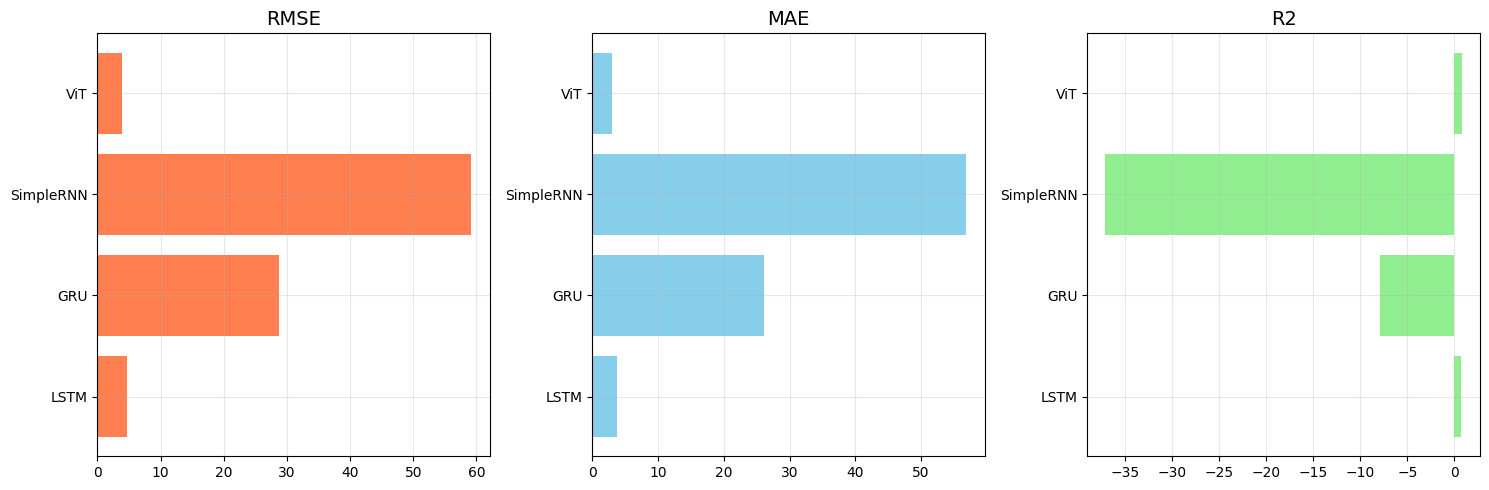

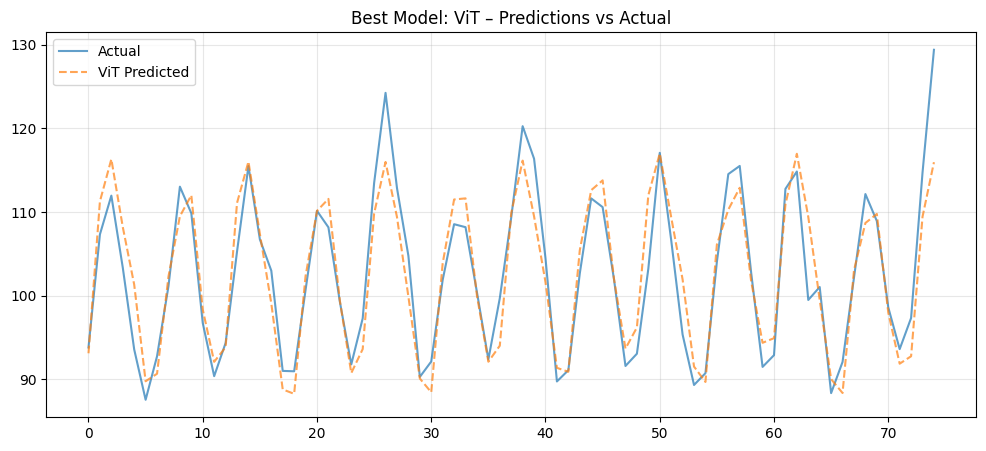

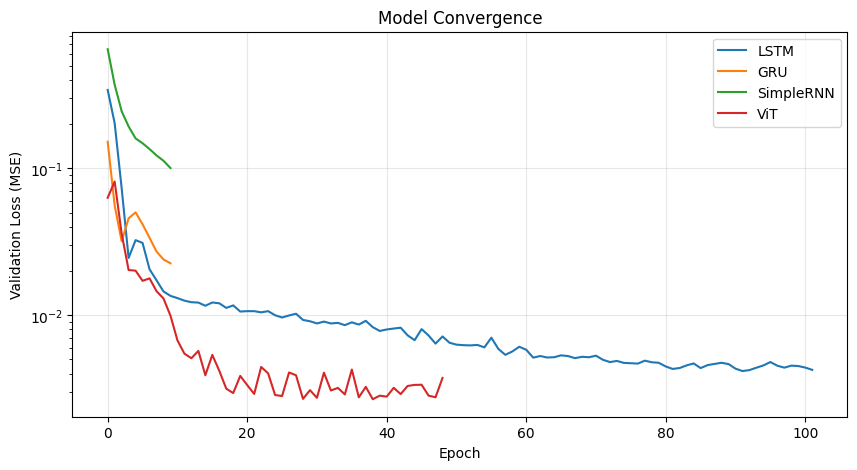

In [16]:
# Plot RMSE, MAE, R2
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models = list(results.keys())

for i, metric in enumerate(['rmse', 'mae', 'r2']):
    values = [results[m][metric] for m in models]
    axes[i].barh(models, values, color=['coral', 'skyblue', 'lightgreen'][i])
    axes[i].set_title(metric.upper(), fontsize=14)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Best model predictions vs actual
best_name = min(results, key=lambda x: results[x]['rmse'])
best = results[best_name]
plt.figure(figsize=(12,5))
plt.plot(best['actual'][:100], label='Actual', alpha=0.7)
plt.plot(best['predictions'][:100], label=f'{best_name} Predicted', alpha=0.7, linestyle='--')
plt.legend()
plt.title(f'Best Model: {best_name} – Predictions vs Actual')
plt.grid(alpha=0.3)
plt.show()

# Training curves (validation loss)
plt.figure(figsize=(10,5))
for name, res in results.items():
    plt.plot(res['history'].history['val_loss'], label=name)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss (MSE)')
plt.title('Model Convergence')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [17]:
print('\n' + '='*60)
print(' FINAL RESULTS & IMPROVEMENTS SUMMARY')
print('='*60)

print('\n🔧 Changes made to align with Kaggle Electric_Production dataset:')
print('1. Date format fixed → pd.to_datetime() auto-detect (monthly data)')
print('2. Removed day_of_week & day_of_month (useless for monthly data)')
print('3. lag7 → lag12 (same month last year = real seasonality signal)')
print('4. rolling_mean_7 → rolling_mean_3 (quarterly trend for monthly data)')
print('5. WINDOW_SIZE 7 → 12 (1 full year lookback for monthly sequences)')
print('6. StandardScaler for features, MinMaxScaler for target')
print('7. EarlyStopping + ReduceLROnPlateau callbacks')
print('8. Vision Transformer (ViT) via HuggingFace as 4th model')

best_name = min(results, key=lambda x: results[x]['rmse'])
best = results[best_name]

print('\n📈 Best model performance:')
print(f'   Model: {best_name}')
print(f'   RMSE:  {best["rmse"]:.3f}')
print(f'   MAE:   {best["mae"]:.3f}')
print(f'   R²:    {best["r2"]:.3f}')

if best['r2'] > 0.8:
    print('   ✅ Excellent – model explains >80% of variance')
elif best['r2'] > 0.6:
    print('   👍 Good – model explains 60-80% of variance')
else:
    print('   ⚠️ Moderate – more tuning may help')

print('\n📉 Model Notes:')
print('   - LSTM/GRU : Best for sequential monthly patterns')
print('   - SimpleRNN: Simpler baseline, may underfit long-range deps')
print('   - ViT      : Treats time-series as pseudo-image via attention')



 FINAL RESULTS & IMPROVEMENTS SUMMARY

🔧 Changes made to align with Kaggle Electric_Production dataset:
1. Date format fixed → pd.to_datetime() auto-detect (monthly data)
2. Removed day_of_week & day_of_month (useless for monthly data)
3. lag7 → lag12 (same month last year = real seasonality signal)
4. rolling_mean_7 → rolling_mean_3 (quarterly trend for monthly data)
5. WINDOW_SIZE 7 → 12 (1 full year lookback for monthly sequences)
6. StandardScaler for features, MinMaxScaler for target
7. EarlyStopping + ReduceLROnPlateau callbacks
8. Vision Transformer (ViT) via HuggingFace as 4th model

📈 Best model performance:
   Model: ViT
   RMSE:  3.810
   MAE:   2.901
   R²:    0.842
   ✅ Excellent – model explains >80% of variance

📉 Model Notes:
   - LSTM/GRU : Best for sequential monthly patterns
   - SimpleRNN: Simpler baseline, may underfit long-range deps
   - ViT      : Treats time-series as pseudo-image via attention
